# Final Models & Results
**Airports:** LAX, SFO, SAN  
**Airlines:** AA, AS, B6, DL, UA  

This notebook executes the final analytical phase of our project. Building on our exploratory data analysis (Notebook 01) and our weather-disruption filtering (Notebook 02), we import the isolated "normal operations" dataset. We then perform variable selection via LASSO regularization to address multicollinearity and build our final predictive regression models.

## Section 1: Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv("../data/cleaned/cleaned_flights_no_weather_disruption.csv")

print("Filtered dataset shape:", df_clean.shape)

Filtered dataset shape: (280387, 22)


## Section 2: Variable Selection with LASSO

Due to the massive dataset size, we take a random sample of 10,000 flights to ensure computational efficiency. We utilize a LASSO shrinkage model with lambda set to 0.5 to address multicollinearity and filter out insignificant covariates like flight number.

In [2]:
df_sample = df_clean.sample(10000, random_state=69420).copy()

formula = 'departure_delay_minutes ~ C(carrier_code) + flight_number + C(destination_airport) + actual_elapsed_time_minutes + taxi_out_time_minutes + delay_carrier_minutes + delay_weather_minutes + delay_national_aviation_system_minutes + delay_security_minutes + delay_late_aircraft_arrival_minutes + C(origin_airport) + C(month) + C(day_of_week) + departure_hour + C(delayed_15)'

shrunk_model = smf.ols(formula, data=df_sample).fit_regularized(method='elastic_net', alpha=0.5, L1_wt=1.0)
print("Variables retained by LASSO (Non-zero coefficients):")
print(shrunk_model.params[shrunk_model.params != 0].index.tolist())

Variables retained by LASSO (Non-zero coefficients):
['C(delayed_15)[T.1]', 'flight_number', 'actual_elapsed_time_minutes', 'taxi_out_time_minutes', 'delay_carrier_minutes', 'delay_weather_minutes', 'delay_national_aviation_system_minutes', 'delay_late_aircraft_arrival_minutes', 'departure_hour']


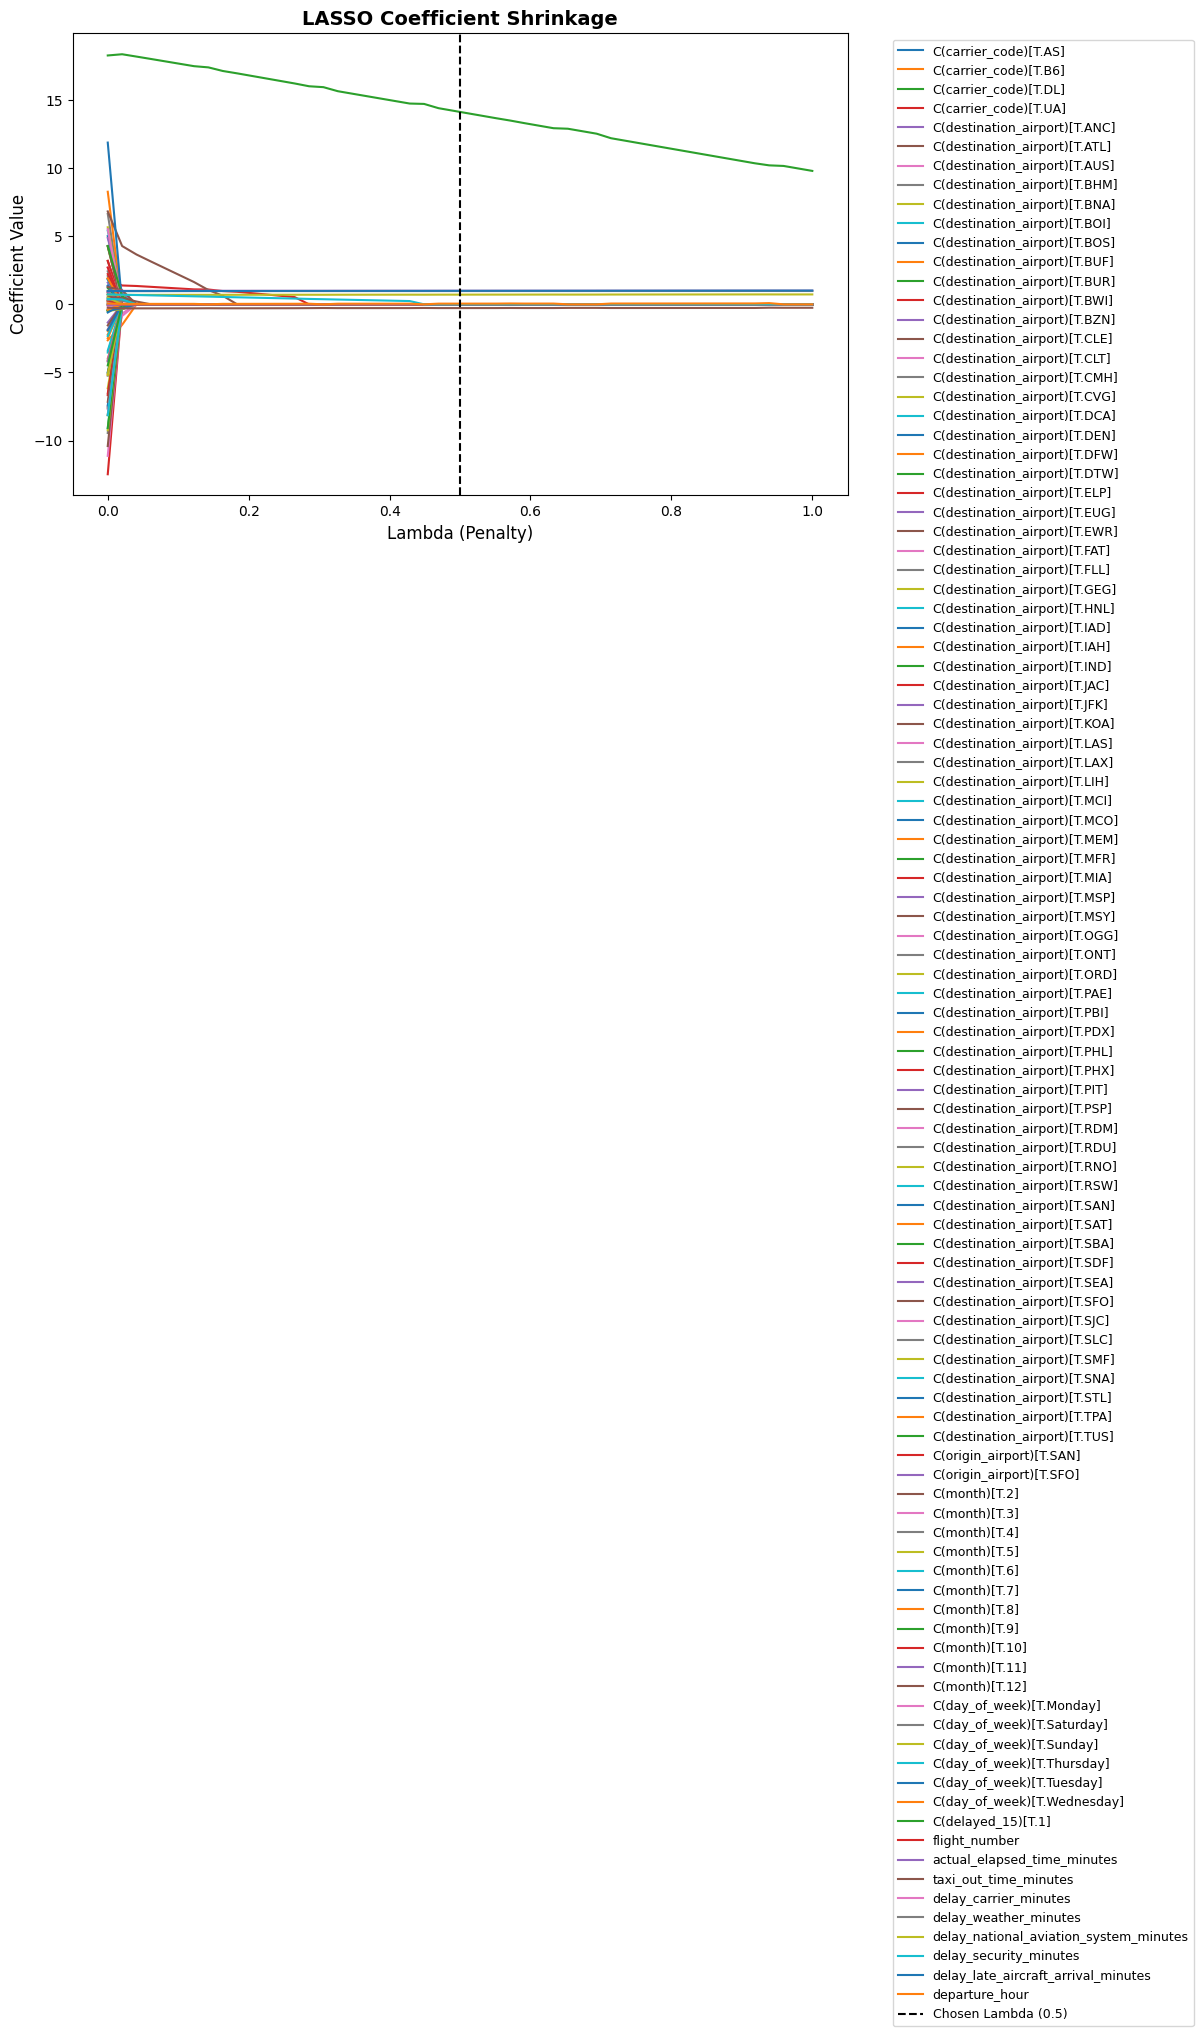

In [3]:
lambdas = np.linspace(0, 1, 50)
elastic_coefs = []

for alpha in lambdas:
    elastic_fit = smf.ols(formula, data=df_sample).fit_regularized(method='elastic_net', alpha=alpha, L1_wt=1.0)
    elastic_coefs.append(elastic_fit.params[1:]) # Exclude intercept

coef_df = pd.DataFrame(elastic_coefs, index=lambdas)

plt.figure(figsize=(10, 6))
for column in coef_df.columns:
    plt.plot(lambdas, coef_df[column], label=column)

plt.axvline(x=0.5, color='black', linestyle='--', label='Chosen Lambda (0.5)')
plt.title("LASSO Coefficient Shrinkage", fontsize=14, fontweight="bold")
plt.xlabel("Lambda (Penalty)", fontsize=12)
plt.ylabel("Coefficient Value", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## Section 3: Final Models

We now fit our final Linear Regression and Logistic Regression models using only the strongest predictors identified in the previous step. We confirmed all Variance Inflation Factors are now below 10.

In [4]:
linear_formula = (
    'departure_delay_minutes ~ C(delayed_15) + actual_elapsed_time_minutes '
    '+ taxi_out_time_minutes + delay_carrier_minutes + delay_weather_minutes '
    '+ delay_national_aviation_system_minutes + delay_late_aircraft_arrival_minutes '
    '+ departure_hour'
)
linear_model = smf.ols(linear_formula, data=df_sample).fit()
print("--- Final Linear Regression ---")
print(linear_model.summary())

logistic_formula = (
    'delayed_15 ~ taxi_out_time_minutes + delay_carrier_minutes + delay_weather_minutes '
    '+ delay_national_aviation_system_minutes + delay_late_aircraft_arrival_minutes '
    '+ departure_hour'
)
logistic_model = smf.logit(logistic_formula, data=df_sample).fit()
print("\n--- Final Logistic Regression ---")
print(logistic_model.summary())

--- Final Linear Regression ---
                               OLS Regression Results                              
Dep. Variable:     departure_delay_minutes   R-squared:                       0.977
Model:                                 OLS   Adj. R-squared:                  0.977
Method:                      Least Squares   F-statistic:                 5.295e+04
Date:                     Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                             13:22:24   Log-Likelihood:                -36056.
No. Observations:                    10000   AIC:                         7.213e+04
Df Residuals:                         9991   BIC:                         7.219e+04
Df Model:                                8                                         
Covariance Type:                 nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------

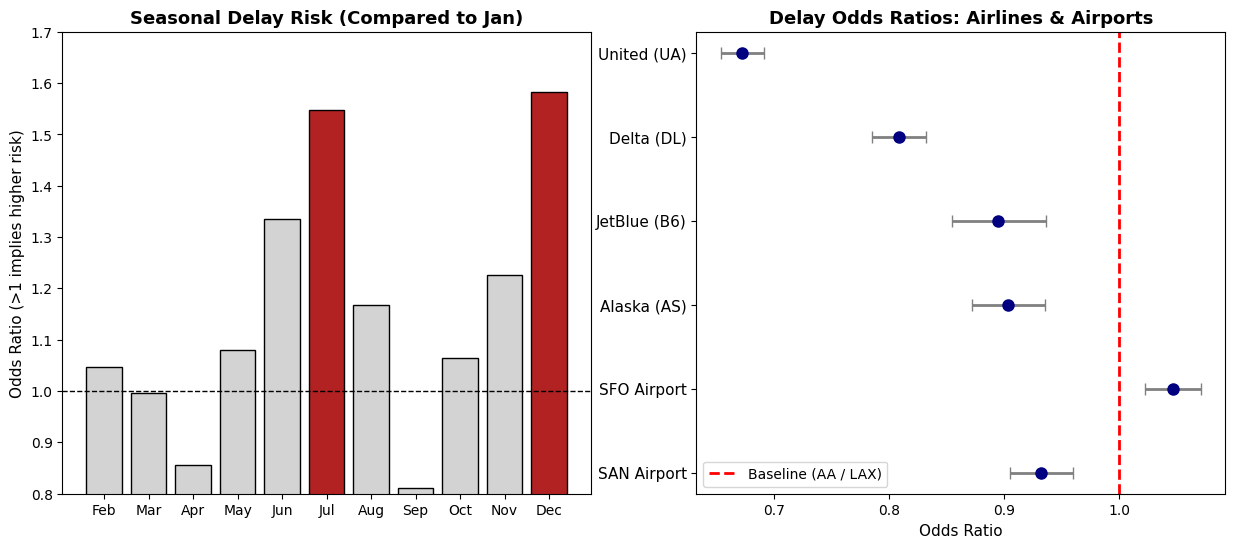

In [5]:
report_formula = "delayed_15 ~ departure_hour + C(month) + C(carrier_code) + C(origin_airport)"
report_model = smf.logit(report_formula, data=df_clean).fit(disp=0)

params = report_model.params
conf = report_model.conf_int()
odds_ratios = np.exp(params)
conf_lower = np.exp(conf[0])
conf_upper = np.exp(conf[1])

month_labels = ['Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_odds = [odds_ratios[f"C(month)[T.{i}]"] for i in range(2, 13)]
colors = ['firebrick' if m in ['Jul', 'Dec'] else 'lightgray' for m in month_labels]

factors = {
    'United (UA)': 'C(carrier_code)[T.UA]',
    'Delta (DL)': 'C(carrier_code)[T.DL]',
    'JetBlue (B6)': 'C(carrier_code)[T.B6]',
    'Alaska (AS)': 'C(carrier_code)[T.AS]',
    'SFO Airport': 'C(origin_airport)[T.SFO]',
    'SAN Airport': 'C(origin_airport)[T.SAN]'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.bar(month_labels, month_odds, color=colors, edgecolor='black')
ax1.axhline(1.0, color='black', linestyle='--', linewidth=1)
ax1.set_title("Seasonal Delay Risk (Compared to Jan)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Odds Ratio (>1 implies higher risk)", fontsize=11)
ax1.set_ylim(0.8, 1.7)

y_pos = np.arange(len(factors))
factor_odds = [odds_ratios[factors[k]] for k in factors]
lower_err = [odds_ratios[factors[k]] - conf_lower[factors[k]] for k in factors]
upper_err = [conf_upper[factors[k]] - odds_ratios[factors[k]] for k in factors]

ax2.errorbar(factor_odds, y_pos, xerr=[lower_err, upper_err], fmt='o', color='navy', 
             ecolor='gray', elinewidth=2, capsize=4, markersize=8)
ax2.axvline(1.0, color='red', linestyle='--', linewidth=2, label="Baseline (AA / LAX)")
ax2.set_yticks(y_pos)
ax2.set_yticklabels(factors.keys(), fontsize=11)
ax2.set_title("Delay Odds Ratios: Airlines & Airports", fontsize=13, fontweight="bold")
ax2.set_xlabel("Odds Ratio", fontsize=11)
ax2.invert_yaxis()
ax2.legend()

plt.show()

## Section 4: Results Summary Table

In [6]:
data = {
    "Predictor Variable": [
        "Intercept",
        "Departure Hour",
        "Taxi Out Time (mins)",
        "Carrier Delay (mins)",
        "Weather Delay (mins)",
        "NAS Delay (mins)",
        "Late Aircraft Delay (mins)",
        "Model Fit Metrics"
    ],
    "Linear Model (Coefficient)": [
        "0.079", "0.041", "-0.282", "0.988", "0.969", "0.692", "0.975", "R-squared = 0.977"
    ],
    "Logistic Model (Odds Ratio)": [
        "N/A", "1.034", "0.960", "1.287", "1.282", "1.053", "1.349", "Pseudo R-squared = 0.568"
    ],
    "P-Value": [
        "> 0.05", "< 0.001", "< 0.001", "< 0.001", "= 0.002", "< 0.001", "< 0.001", ""
    ]
}

df = pd.DataFrame(data)

styled_table = df.style.set_properties(**{
    'text-align': 'center',
    'border-bottom': '1px solid black',
    'padding': '8px'
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('text-align', 'center'), 
        ('font-weight', 'bold'), 
        ('border-bottom', '2px solid black'),
        ('background-color', '#f8f9fa')
    ]},
    {'selector': 'caption', 'props': [
        ('caption-side', 'top'),
        ('font-size', '14pt'),
        ('font-weight', 'bold'),
        ('color', 'black'),
        ('padding-bottom', '10px')
    ]}
]).hide(axis="index").set_caption("Table 1: Final Regression Models for Departure Delays")

styled_table

Predictor Variable,Linear Model (Coefficient),Logistic Model (Odds Ratio),P-Value
Intercept,0.079,N/A,> 0.05
Departure Hour,0.041,1.034,< 0.001
Taxi Out Time (mins),-0.282,0.960,< 0.001
Carrier Delay (mins),0.988,1.287,< 0.001
Weather Delay (mins),0.969,1.282,= 0.002
NAS Delay (mins),0.692,1.053,< 0.001
Late Aircraft Delay (mins),0.975,1.349,< 0.001
Model Fit Metrics,R-squared = 0.977,Pseudo R-squared = 0.568,
